# Source code for predicting whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('bank_marketing.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.shape

(11162, 17)

In [4]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


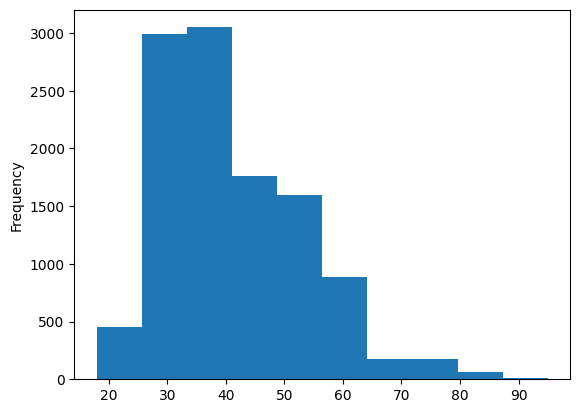

In [6]:
df['age'].plot(kind='hist');

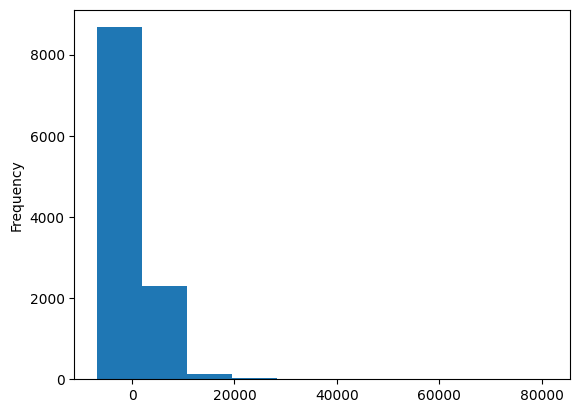

In [7]:
df['balance'].plot(kind='hist');

In [8]:
binary_cols = ['default', 'housing', 'loan', 'deposit']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [9]:
education_map = {
    'primary': 1,
    'secondary': 2,
    'tertiary': 3,
    'unknown': 0  # Treat unknown as a separate category or neutral
}
df['education'] = df['education'].map(education_map)

In [10]:
nominal_cols = ['job', 'marital', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [11]:
df.shape

(11162, 41)

In [12]:
df.head()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2,0,2343,1,0,5,1042,1,-1,...,False,False,False,True,False,False,False,False,False,True
1,56,2,0,45,0,0,5,1467,1,-1,...,False,False,False,True,False,False,False,False,False,True
2,41,2,0,1270,1,0,5,1389,1,-1,...,False,False,False,True,False,False,False,False,False,True
3,55,2,0,2476,1,0,5,579,1,-1,...,False,False,False,True,False,False,False,False,False,True
4,54,3,0,184,0,0,5,673,2,-1,...,False,False,False,True,False,False,False,False,False,True


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, classification_report

In [14]:
X = df.drop('deposit', axis=1)
y = df['deposit']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
lr_model = LogisticRegression()
rf_model = RandomForestClassifier(random_state=42)

In [18]:
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

print("Models trained successfully.")

Models trained successfully.


In [19]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [20]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

Random Forest Confusion Matrix:
[[955 211]
 [144 923]]
F1-Score: 0.8387


In [21]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

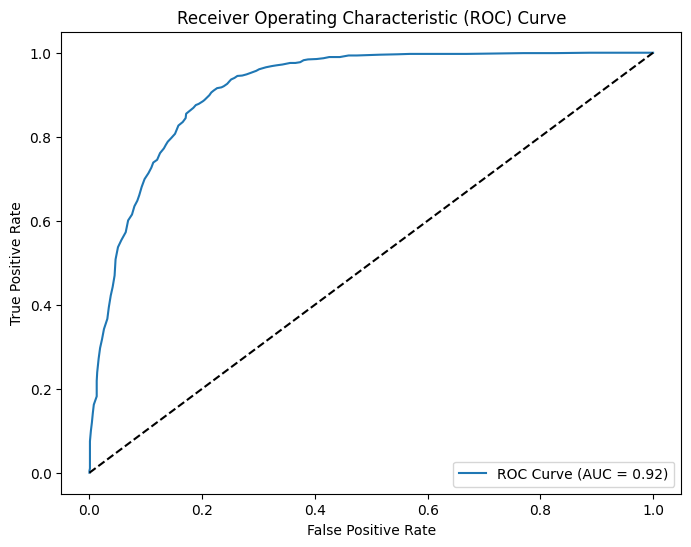

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
import shap

# Initialize the SHAP Explainer (TreeExplainer is best for Random Forest)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# 1. Summary Plot (Overall feature importance)
shap.summary_plot(shap_values[1], X_test, feature_names=X.columns)

# 2. Explaining 5 individual predictions
# We'll visualize the first 5 samples from the test set
shap.initjs() # Required for notebook visualization

for i in range(5):
    print(f"Explanation for Sample {i}:")
    # Using a force plot for local explanation
    display(shap.force_plot(explainer.expected_value[1], shap_values[1][i], X_test.iloc[i], feature_names=X.columns))